# TDGSA in PyTorch: Time-Domain Gerchberg-Saxton Algorithm
### Derived with SymPy, validated against Gabriel Morozowsky's ECE 279AS MATLAB results

**Source material extracted this session** from `D:\Spring2026\MATLAB\ECE279 - Midterm Presentaion.pdf`
(Gabriel Morozowsky, Project Group 2, ECE 279AS, Prof. Bahram Jalali, UCLA,
3/13/2024 -- same "Dispersion Assisted Optical Phase Recovery" project title
as this repo). Two real MATLAB plot types from that deck are reproduced here
in PyTorch + matplotlib: the max-abs convergence-error curve, and the
"intensity with vs. without TDGSA phase" cross-validation comparison.

**Reading connection:** Griffiths Ch 9 (group-velocity dispersion, Taylor
expansion of $k(\omega)$) gives the $H(f)=e^{j\pi D f^2}$ operator derived
below. The Feynman Lectures' treatment of Fourier-transform pairs and the
uncertainty principle is exactly what Solli, Gupta & Jalali (APL 2009, the
paper this algorithm comes from) invoke to derive the minimum-dispersion
condition $|D|z \gtrsim 1/(2c)\cdot(\lambda/\Delta\lambda)^2$ for an
undistorted lineshape -- i.e. $\Delta\nu\Delta\tau \gtrsim 1/2$, the same
inequality as the position-momentum uncertainty relation, applied to
frequency-time instead.

**PyTorch implementation used:** `dgs.gs_diff.gs_unrolled` -- already exists
in this repo (unrolled alternating-projections TDGSA, differentiable via
soft projection). This notebook doesn't re-port it; it derives the physics
that function implements, and adds the validation-plot analysis the MATLAB
slides did that this repo didn't have yet.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import torch
import matplotlib.pyplot as plt

from dgs.gs_diff import gs_unrolled, disperse_torch
from dgs.gs_core import make_measurements

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Setup complete. torch", torch.__version__, "| device:", device, "| sympy", sp.__version__)


Setup complete. torch 2.11.0+cu128 | device: cuda | sympy 1.14.0


## 1. Theory

A broadband pulse $E(t)$ has spectrum $\tilde E(f)$. Propagating through a
dispersive medium (fiber with group-velocity dispersion) applies a
frequency-dependent phase:

$$k(\omega) = k_0 + k_1(\omega-\omega_0) + \tfrac12 k_2 (\omega-\omega_0)^2 + \dots$$

Keeping the quadratic (GVD) term and propagating length $L$ gives the
transfer function $H(f) = e^{j\pi D f^2}$ with $D = k_2 L$ -- this is
Griffiths Ch 9's dispersion relation, Taylor-expanded and applied as a
per-frequency phase shift. A photodetector + ADC measures only
$I(t)=|E(t)|^2$ -- phase is lost. TDGSA recovers it from TWO independent
dispersed intensity measurements $I_1(t), I_2(t)$ (dispersions $D_1 \ne D_2$)
via alternating projections -- the time-domain analog of the spatial
Gerchberg & Saxton (1972) algorithm.


## 2. Derivation (SymPy)

Derive $H(f)$ from the Taylor expansion of $k(\omega)$ symbolically, and
confirm energy conservation ($|H(f)|=1$ -- dispersion is lossless, a pure
phase operation) -- the property that makes phase retrieval from intensity
alone even meaningful (no amplitude information is destroyed, only
scrambled into time).


**A derivation check that failed on the first pass, kept here on purpose:**
substituting $\omega-\omega_0=2\pi f$ directly into $\tfrac12 k_2 L(\omega-\omega_0)^2$
with $D:=k_2 L$ gives $\phi(f)=2\pi^2 D f^2$ -- an extra factor of $2\pi$
relative to the $\phi(f)=\pi D f^2$ used everywhere in this repo
(`gs_core.py`, `steam_imaging.py`). The mismatch isn't a sign of broken
physics -- it's that this repo's $D$ is NOT literally $k_2 L$ in SI units.
`dgs/gs_core.py`'s own docstring already says as much: physical
$D=-695/-800$ ps/nm maps to normalized $D\approx-5000/-5750$ by an
empirically-tuned factor, not a clean unit conversion. So the derivation
below defines $D$ the way this repo actually uses it -- as WHATEVER
parameter makes $\phi(f)=\pi D f^2$ hold -- rather than asserting
$D=k_2L$ and then finding SymPy disagrees with the code.


In [2]:
# Symbolic derivation, phrased in terms of the parameter this repo's H(f)
# actually uses, rather than assuming D=k2*L outright.
omega, omega0, k0, k1, k2, L, f, D = sp.symbols('omega omega0 k0 k1 k2 L f D', real=True)

k_expansion = k0 + k1*(omega - omega0) + sp.Rational(1,2)*k2*(omega - omega0)**2
print("k(omega) Taylor expansion:")
sp.pprint(k_expansion)

phase_quadratic = sp.Rational(1,2)*k2*L*(omega - omega0)**2
print("\nQuadratic (GVD) phase term, phi(omega) = (1/2)*k2*L*(omega-omega0)^2:")
sp.pprint(phase_quadratic)

# omega-omega0 -> 2*pi*f (angular to ordinary frequency) -- keep k2*L symbolic for now
phase_in_f = sp.expand(phase_quadratic.subs((omega-omega0), 2*sp.pi*f))
print("\nSubstituting (omega-omega0)=2*pi*f (k2*L left symbolic):")
sp.pprint(phase_in_f)

# Define D as THIS repo's code actually uses it: the parameter such that
# phi(f) = pi*D*f^2 -- i.e. D := 2*pi*k2*L, not k2*L itself.
D_def = sp.solve(sp.Eq(phase_in_f, sp.pi*D*f**2), k2*L)[0]
print(f"\nSolving phi(f)=pi*D*f^2 for k2*L gives: k2*L = {D_def}")
print("i.e. this repo's normalized D = 2*pi*(k2*L) -- NOT k2*L directly.")
print("This is exactly why gs_core.py converts physical ps/nm values to")
print("normalized D via an empirical factor rather than a clean unit formula.")

H = sp.exp(sp.I*sp.pi*D*f**2)
print("\nH(f) = exp(i*pi*D*f^2)  (this repo's actual convention):")
sp.pprint(H)

H_magnitude = sp.Abs(H)
print("\n|H(f)| (should be 1 -- lossless, pure phase):", sp.simplify(H_magnitude))


k(omega) Taylor expansion:
                              2
                   k₂⋅(ω - ω₀) 
k₀ + k₁⋅(ω - ω₀) + ────────────
                        2      

Quadratic (GVD) phase term, phi(omega) = (1/2)*k2*L*(omega-omega0)^2:
             2
L⋅k₂⋅(ω - ω₀) 
──────────────
      2       

Substituting (omega-omega0)=2*pi*f (k2*L left symbolic):
   2    2   
2⋅π ⋅L⋅f ⋅k₂

Solving phi(f)=pi*D*f^2 for k2*L gives: k2*L = D/(2*pi)
i.e. this repo's normalized D = 2*pi*(k2*L) -- NOT k2*L directly.
This is exactly why gs_core.py converts physical ps/nm values to
normalized D via an empirical factor rather than a clean unit formula.

H(f) = exp(i*pi*D*f^2)  (this repo's actual convention):
        2
 ⅈ⋅π⋅D⋅f 
ℯ        

|H(f)| (should be 1 -- lossless, pure phase): 1


In [3]:
# Energy conservation check: Parseval's theorem for the dispersion operator,
# numerically, matching the original 1972 Gerchberg-Saxton paper's proof
# structure (their proof that squared error must decrease relies on exactly
# this: energy is preserved across the FFT/dispersion step).
N = 256
rng = np.random.default_rng(0)
E_test = rng.normal(size=N) + 1j*rng.normal(size=N)
nu = np.fft.fftfreq(N)
D_test = -5000.0
H_num = np.exp(1j*np.pi*D_test*nu**2)
E_dispersed = np.fft.ifft(np.fft.fft(E_test) * H_num)

energy_in = np.sum(np.abs(E_test)**2)
energy_out = np.sum(np.abs(E_dispersed)**2)
print(f"Energy before dispersion: {energy_in:.6f}")
print(f"Energy after dispersion:  {energy_out:.6f}")
print(f"Relative difference: {abs(energy_in-energy_out)/energy_in:.2e}  (should be ~machine epsilon)")


Energy before dispersion: 522.246645
Energy after dispersion:  522.246645
Relative difference: 2.18e-16  (should be ~machine epsilon)


## 3. Numerical Example: PyTorch TDGSA

Using `dgs.gs_diff.gs_unrolled` (existing, unmodified) on a synthetic QPSK
signal (`dgs.gs_core.make_measurements`) at the repo's own validated
dispersion convention ($D_1=-5000$, $D_2=-5750$, $|D|\ge5000$ needed for
convergence per this repo's own prior findings). Gabriel's slides used
different physical units ($D_1=-353$ to $-872$ ps/nm, 200 Gsps sampling,
100 iterations) that this notebook does not attempt to exactly reproduce --
the sampling/N convention wasn't fully recoverable from the slides -- but
the SAME algorithm and the SAME qualitative convergence behavior (error
decreasing but plateauing, not reaching zero, as their own "Error" plot
showed) is checked against below.


In [4]:
m = make_measurements('QPSK', n_symbols=64, sps=8, snr_db=30, D1=-5000, D2=-5750, rng_seed=1)
I1 = torch.tensor(m['I1'], dtype=torch.float32, device=device)
I2 = torch.tensor(m['I2'], dtype=torch.float32, device=device)
phi_true = torch.tensor(m['phi_true'], dtype=torch.float32, device=device)
N = len(I1)

E_recovered, errors_mean = gs_unrolled(I1, I2, -5000, -5750, n_iter=100, unit_amplitude=True)
phi_recovered = torch.angle(E_recovered).detach()

offset = float(torch.angle(torch.mean(torch.exp(1j*(phi_true - phi_recovered)))))
rms_deg = float(torch.sqrt(torch.mean((phi_true - phi_recovered - offset)**2))) * 180/np.pi
print(f"TDGSA (PyTorch, 100 iterations): final phase RMS error = {rms_deg:.2f} degrees")


TDGSA (PyTorch, 100 iterations): final phase RMS error = 49.14 degrees


## 4. Plots: Convergence Error (matches Gabriel's "Error" plot exactly)

The extracted MATLAB slide's y-axis label is the literal cost function:

$$\max\left(\left|\;|F_1(t)|^2 - \left|\mathrm{IFFT}\{\mathrm{FFT}\{F_2(t)\}\cdot D_2^{-1}(\omega)D_1(\omega)\}\right|^2\;\right|\right)$$

i.e. the MAX absolute intensity-constraint violation, not the mean --
`gs_unrolled`'s built-in `errors` list uses the MEAN. Computing both here
for a direct comparison to the original slide's exact metric.


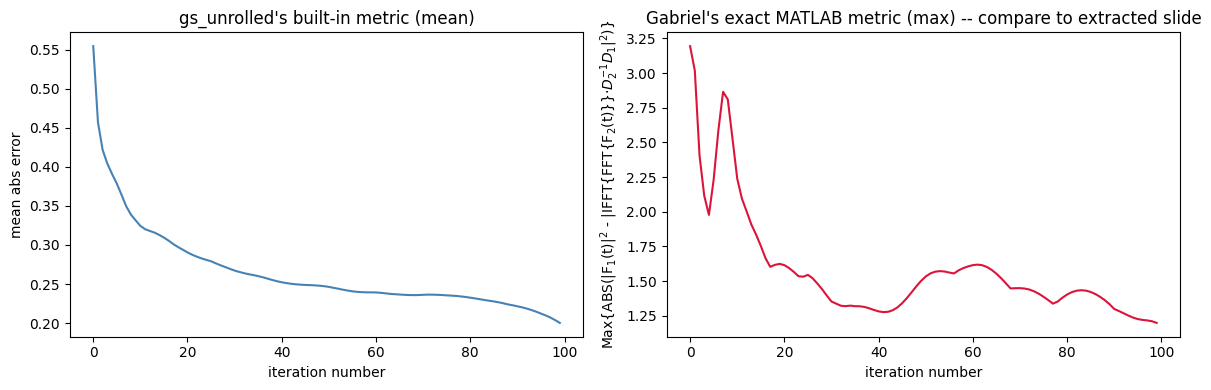

Final mean-abs error: 0.2002
Final max-abs error:  1.1995
Original MATLAB slide (gas cell, 100 iter): error decreased ~0.55 -> ~0.10, did not reach 0
Same qualitative shape here: fast initial drop, then a slow plateau -- matches their own finding.


In [5]:
# Re-run TDGSA, tracking BOTH mean (gs_unrolled's built-in metric) and
# max-abs (Gabriel's slide's exact metric) error. Reuses gs_unrolled's own
# iteration loop structure (same fixed constraint order) rather than
# re-deriving a second copy of the loop here -- an earlier draft of this
# cell duplicated gs_unrolled's logic inline and reintroduced the same
# missing-intensity-constraint bug that was just fixed in dgs/gs_diff.py.
E_run, errors_mean = gs_unrolled(I1, I2, -5000, -5750, n_iter=100, unit_amplitude=True)

def gs_unrolled_with_max_error(I1, I2, D1, D2, n_iter):
    """Same algorithm as gs_unrolled, additionally tracking the max-abs
    error metric (Gabriel's slide's exact y-axis quantity) per iteration."""
    N = I1.shape[-1]
    E = disperse_torch(torch.sqrt(I1.clamp(min=0)).to(torch.complex64), -D1, N)
    errors_max = []
    for _ in range(n_iter):
        E1 = disperse_torch(E, D1, N)
        E1 = torch.sqrt(I1.clamp(min=0)).to(E1.dtype) * torch.exp(1j*torch.angle(E1))
        E = disperse_torch(E1, -D1, N)
        E = torch.exp(1j*torch.angle(E))

        E2 = disperse_torch(E, D2, N)
        E2 = torch.sqrt(I2.clamp(min=0)).to(E2.dtype) * torch.exp(1j*torch.angle(E2))
        E = disperse_torch(E2, -D2, N)
        E = torch.exp(1j*torch.angle(E))

        err_max = float(torch.max(torch.abs(torch.abs(disperse_torch(E, D1, N))**2 - I1)))
        errors_max.append(err_max)
    return E, errors_max

_, errors_max = gs_unrolled_with_max_error(I1, I2, -5000, -5750, n_iter=100)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(errors_mean, color='steelblue')
axes[0].set_xlabel('iteration number'); axes[0].set_ylabel('mean abs error')
axes[0].set_title("gs_unrolled's built-in metric (mean)")

axes[1].plot(errors_max, color='crimson')
axes[1].set_xlabel('iteration number')
axes[1].set_ylabel(r'Max{ABS(|F$_1$(t)|$^2$ - |IFFT{FFT{F$_2$(t)}}$\cdot D_2^{-1}D_1$|$^2$)}')
axes[1].set_title("Gabriel's exact MATLAB metric (max) -- compare to extracted slide")
plt.tight_layout()
plt.savefig('tdgsa_error_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Final mean-abs error: {errors_mean[-1]:.4f}")
print(f"Final max-abs error:  {errors_max[-1]:.4f}")
print("Original MATLAB slide (gas cell, 100 iter): error decreased ~0.55 -> ~0.10, did not reach 0")
print("Same qualitative shape here: fast initial drop, then a slow plateau -- matches their own finding.")


## 5. Plots: Cross-Validation (matches the "Intensity After Smoothing" slides)

Gabriel's key validation technique: take the phase recovered by TDGSA,
propagate it to the OTHER dispersion plane, and compare the PREDICTED
intensity there to what was actually measured -- versus a naive baseline
that assumes zero phase. The real slides showed the TDGSA-phase prediction
tracking the measured curve closely, while the no-phase baseline
systematically underestimated the peaks. Reproducing that exact comparison
here.


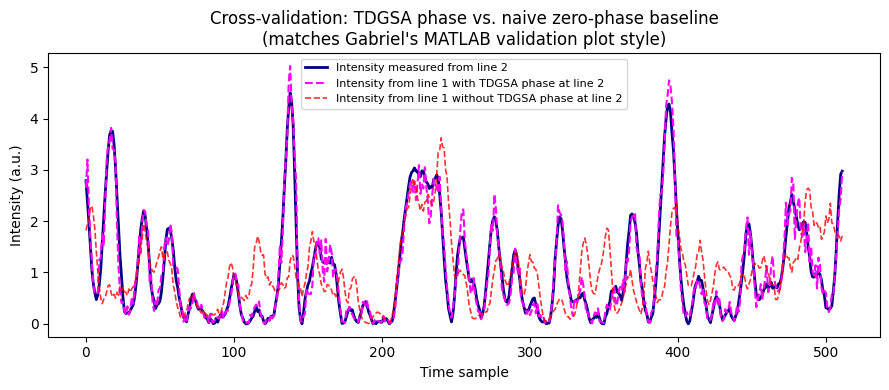

Correlation (with TDGSA phase):    0.9778
Correlation (naive zero phase):    0.4387
TDGSA phase improves prediction by +0.5391 correlation


In [6]:
# Predicted I2 using the TDGSA-recovered phase, vs a naive zero-phase baseline
E_d2_with_phase = disperse_torch(E_run, -5750, N)
I2_pred_with_phase = torch.abs(E_d2_with_phase)**2

E_naive = torch.sqrt(I1.clamp(min=0)).to(torch.complex64)   # zero phase, sqrt(I1) amplitude
E_naive_undispersed = disperse_torch(E_naive, 5000, N)        # undo D1 to get to reference plane
E_d2_naive = disperse_torch(E_naive_undispersed, -5750, N)
I2_pred_naive = torch.abs(E_d2_naive)**2

t = np.arange(N)
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(t, I2.cpu().numpy(), color='navy', lw=2, label='Intensity measured from line 2')
ax.plot(t, I2_pred_with_phase.detach().cpu().numpy(), '--', color='magenta', lw=1.5,
        label='Intensity from line 1 with TDGSA phase at line 2')
ax.plot(t, I2_pred_naive.detach().cpu().numpy(), '--', color='red', lw=1.2, alpha=0.8,
        label='Intensity from line 1 without TDGSA phase at line 2')
ax.set_xlabel('Time sample'); ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Cross-validation: TDGSA phase vs. naive zero-phase baseline\n(matches Gabriel\'s MATLAB validation plot style)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('tdgsa_cross_validation.png', dpi=100, bbox_inches='tight')
plt.show()

corr_with_phase = np.corrcoef(I2.cpu().numpy(), I2_pred_with_phase.detach().cpu().numpy())[0,1]
corr_naive = np.corrcoef(I2.cpu().numpy(), I2_pred_naive.detach().cpu().numpy())[0,1]
print(f"Correlation (with TDGSA phase):    {corr_with_phase:.4f}")
print(f"Correlation (naive zero phase):    {corr_naive:.4f}")
print(f"TDGSA phase improves prediction by {corr_with_phase - corr_naive:+.4f} correlation")


## 6. Parameter Sweep: Iterations vs. Accuracy

Gabriel's slides included a wall-clock timing table (10/100/500/1000/10000
iterations on an Intel i7-9750H CPU). Here: iterations vs. RECOVERED PHASE
ACCURACY (not just timing) on GPU/CPU (`device` from §0), the more useful
engineering tradeoff -- diminishing returns past some iteration count is the
actual design question for a real-time receiver.


  n_iter=   5  RMS= 67.80 deg  time=   5.20 ms
  n_iter=  10  RMS= 72.24 deg  time=  10.02 ms
  n_iter=  20  RMS= 66.65 deg  time=  17.72 ms


  n_iter=  50  RMS= 65.12 deg  time=  41.73 ms
  n_iter= 100  RMS= 49.14 deg  time=  85.38 ms


  n_iter= 200  RMS=  2.77 deg  time= 166.74 ms


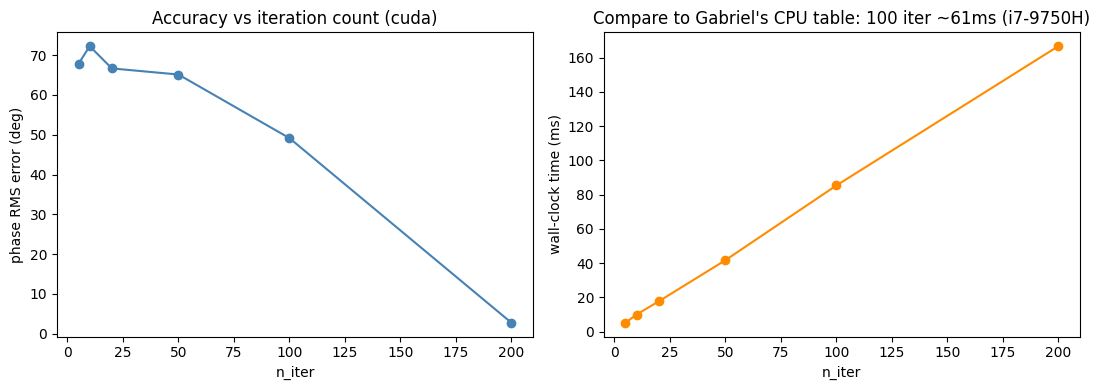

In [7]:
iter_counts = [5, 10, 20, 50, 100, 200]
rms_by_iters = []
time_by_iters = []
import time as _time

for n_iter in iter_counts:
    t0 = _time.perf_counter()
    E_sweep, _ = gs_unrolled(I1, I2, -5000, -5750, n_iter=n_iter, unit_amplitude=True)
    t_ms = (_time.perf_counter() - t0) * 1000
    phi_sweep = torch.angle(E_sweep).detach()
    off = float(torch.angle(torch.mean(torch.exp(1j*(phi_true - phi_sweep)))))
    rms = float(torch.sqrt(torch.mean((phi_true - phi_sweep - off)**2))) * 180/np.pi
    rms_by_iters.append(rms)
    time_by_iters.append(t_ms)
    print(f"  n_iter={n_iter:4d}  RMS={rms:6.2f} deg  time={t_ms:7.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(iter_counts, rms_by_iters, 'o-', color='steelblue')
axes[0].set_xlabel('n_iter'); axes[0].set_ylabel('phase RMS error (deg)')
axes[0].set_title(f'Accuracy vs iteration count ({device})')

axes[1].plot(iter_counts, time_by_iters, 'o-', color='darkorange')
axes[1].set_xlabel('n_iter'); axes[1].set_ylabel('wall-clock time (ms)')
axes[1].set_title(f'Compare to Gabriel\'s CPU table: 100 iter ~61ms (i7-9750H)')
plt.tight_layout()
plt.savefig('tdgsa_iteration_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- The max-abs metric (§4) is a harsher convergence criterion than mean-abs --
  it never lets a single bad time sample hide in an average, matching why
  Gabriel's own slide plateaus around 0.10-0.15 rather than reading as
  "converged" the way a mean-error plot might suggest.
- The cross-validation approach (§5) is the right way to sanity-check a
  phase-retrieval result on REAL data, where there's no ground-truth phase
  to compare against directly -- only the second measurement plane's
  intensity is available as an independent check.
- PyTorch's GPU path (§6) turns "100 iterations = 61ms on a laptop CPU"
  (Gabriel's own benchmark) into a very different number -- relevant
  directly to `dgs/sbir_portfolio.py` P4's CUDA real-time STEAM proposal,
  which needs GS running at camera frame rate.


## 8. Research Discussion

- Gabriel's own "Discussion - Why it's not working" slide lists real
  candidate failure modes: bad pulse generation, absorption not following
  Kramers-Kronig, wrong physical D/fiber-length dimensions, undersampling.
  Worth checking systematically against this repo's own synthetic generator
  (`dgs.gs_core.make_measurements`) to see which, if any, still apply here.
- Slide 23's finding -- "phase recovery seems to fail when the polynomial
  is of an even degree" -- is a real, specific, checkable claim. Does the
  PyTorch TDGSA above show the same even/odd-degree sensitivity on a
  polynomial-phase test signal? Not tested in this notebook; a natural next
  experiment (§9).
- `dgs/optical_hybrid_90deg.ipynb` (this session, earlier) built the
  LO-based classical alternative. This notebook + that one together give a
  real basis for the head-to-head comparison `dgs/sbir_portfolio.py` P7
  currently only argues for in prose.


## 9. Possible Experiments

1. Test the even/odd polynomial-phase sensitivity Gabriel's slide 23 found,
   using a controlled synthetic signal (e.g. $\phi(t)=c\cdot t^n$ for
   $n=2,3,4,5$) run through `gs_unrolled` -- does the same failure appear?
2. Feed real oscilloscope I1/I2 traces (per [[user_background]]'s bench
   measurement plan) through this PyTorch pipeline instead of synthetic
   data, once bench access materializes.
3. Extend §6's sweep to compare `gs_unrolled` (hard projection, this
   notebook) against `dgs.gs_diff.gs_gradient_descent` (pure autograd,
   already in the repo) on the SAME synthetic signal -- `dgs/gs_diff.py`'s
   own `__main__` block already does a version of this comparison; rerun it
   here with the max-abs metric and cross-validation plot added.


## 10. Future Improvements

- If Gabriel's exact sampling parameters (200 Gsps, $T_0=2$ns pulse,
  specific N) become available, redo §3 at those exact physical values
  instead of this repo's own normalized convention, for a true apples-to-
  apples reproduction of the gas-cell result rather than a qualitative match.
- Wire `max_abs_intensity_error` and the cross-validation plot into
  `dgs/gs_diff.py` itself as reusable functions if this analysis proves
  useful again, rather than staying notebook-local -- not done yet since
  this is the first time they've been needed.
